In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("Advertising.csv", index_col=0)

In [5]:
print(df.shape)

(200, 4)


In [6]:
print(df.dtypes)

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


In [7]:
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [8]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


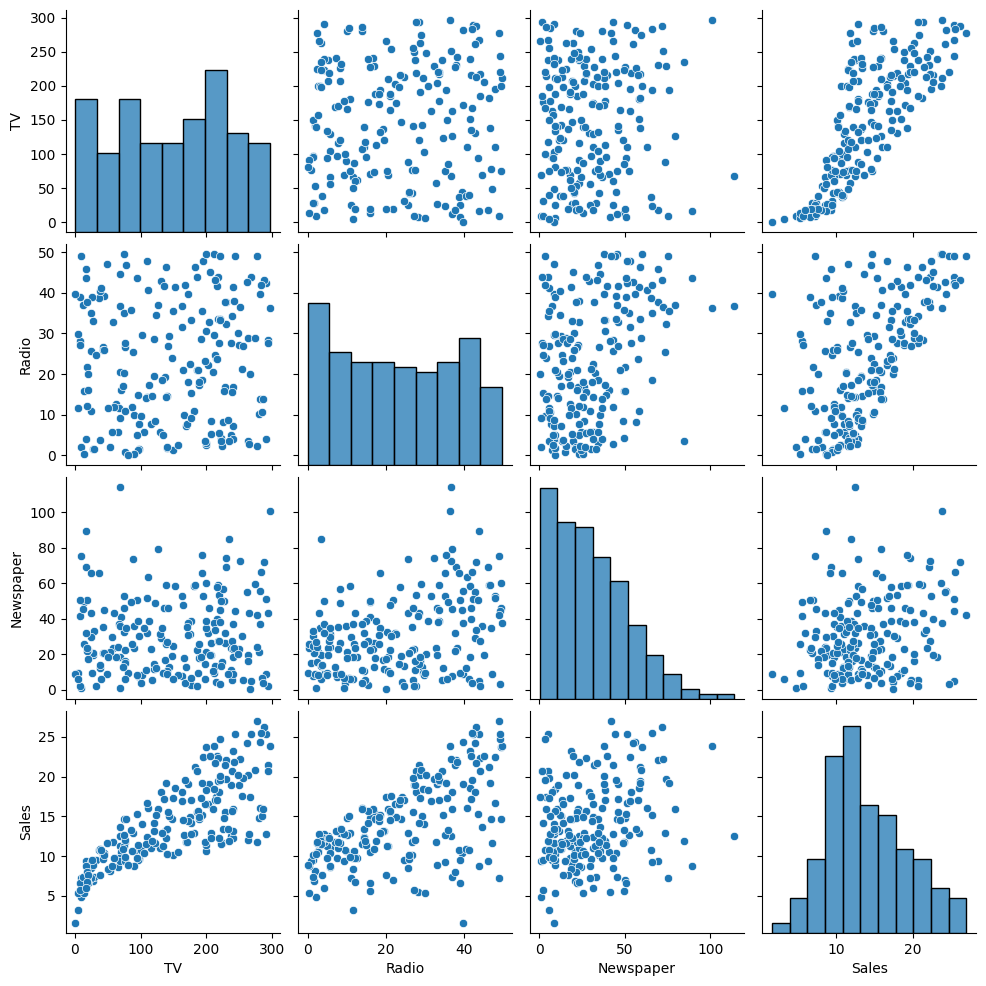

In [9]:
sns.pairplot(df)

plt.show()

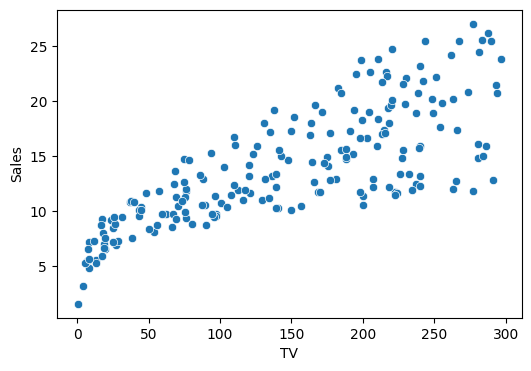

In [10]:
#Sales vs TV
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='TV',
    y='Sales',
    data=df
)
plt.show()

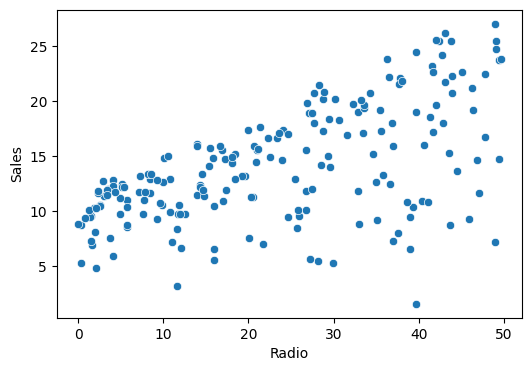

In [11]:
# Sales vs Radio
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Radio',
    y='Sales',
    data=df
)
plt.show()

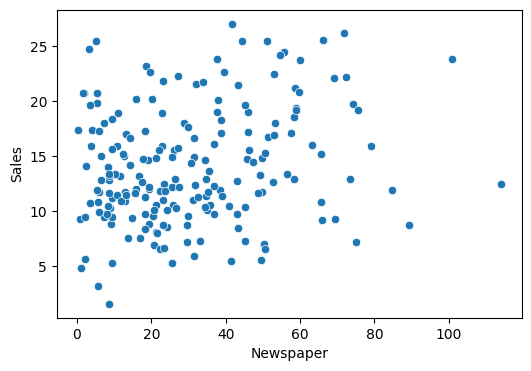

In [12]:
#Sales vs Newspaper
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Newspaper',
    y='Sales',
    data=df
)
plt.show()

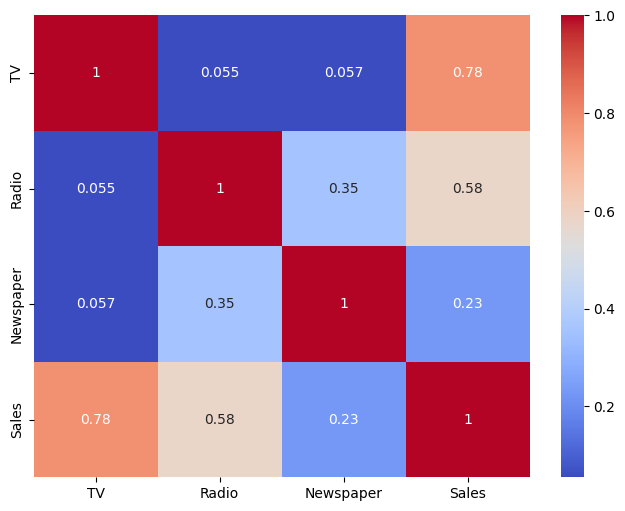

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [14]:
X = df[['TV','Radio','Newspaper']]

y = df['Sales']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(X_test)

In [17]:
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

print(mae_lr)

1.4607567168117603


In [18]:
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

print(mae_lr)

1.4607567168117603


In [19]:
rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

print(rmse_lr)

1.78159966153345


In [20]:
r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print(r2_lr)

0.899438024100912


In [21]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(X_test)

In [22]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

MAE: 0.6200999999999988
RMSE: 0.7685910811348248
R²: 0.9812843792541843


In [23]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Random Forest'
    ],
    'MAE':[
        mae_lr,
        mae_rf
    ],
    'RMSE':[
        rmse_lr,
        rmse_rf
    ],
    'R2 Score':[
        r2_lr,
        r2_rf
    ]
})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  1.460757  1.781600  0.899438
1      Random Forest  0.620100  0.768591  0.981284


In [24]:
if r2_rf > r2_lr:
    best_model = rf
    best_pred = y_pred_rf
    print("Random Forest is Best")
else:
    best_model = lr
    best_pred = y_pred_lr
    print("Linear Regression is Best")

Random Forest is Best


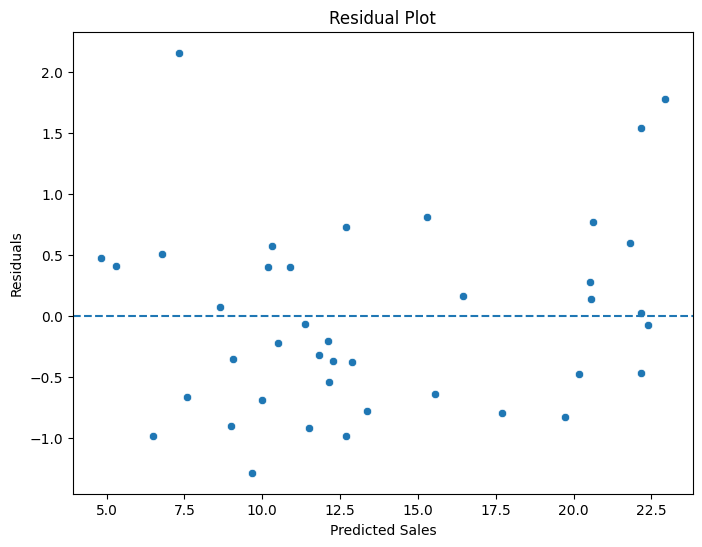

In [25]:
residuals = y_test - best_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=best_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [26]:
coef_df = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':lr.coef_
})

print(coef_df)

     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


In [27]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

print(
    importance.sort_values(
        by='Importance',
        ascending=False
    )
)

     Feature  Importance
0         TV    0.624810
1      Radio    0.362201
2  Newspaper    0.012989
